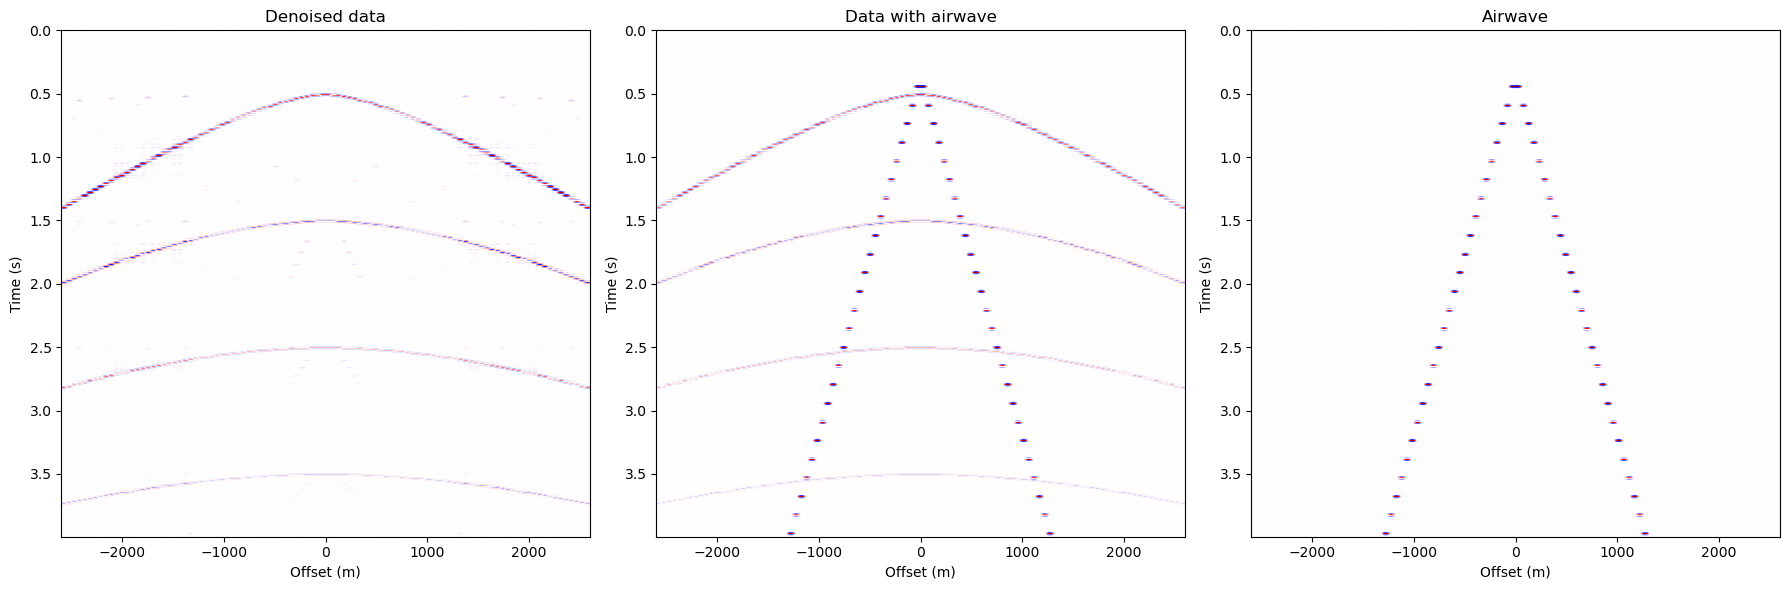

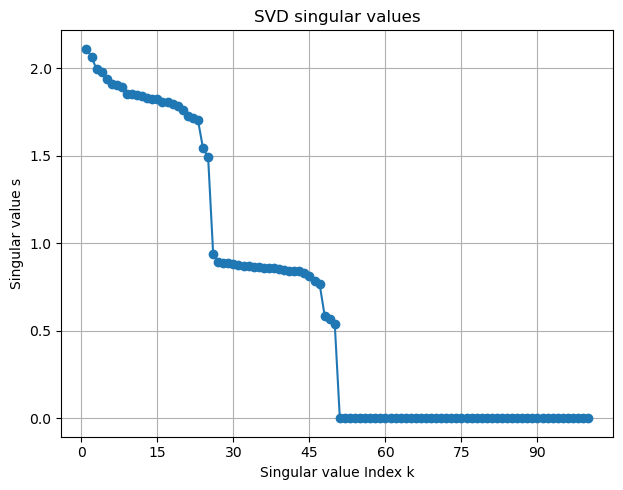

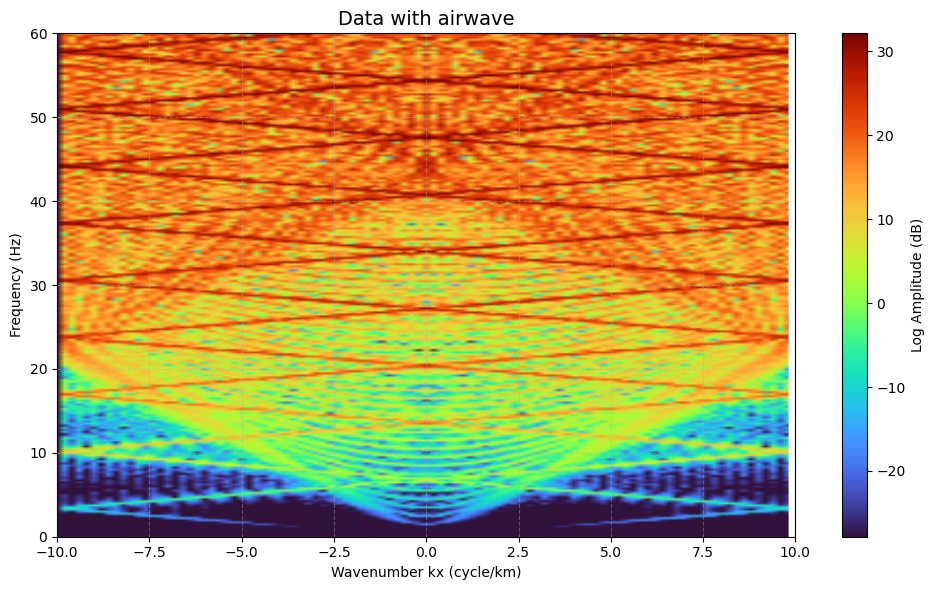

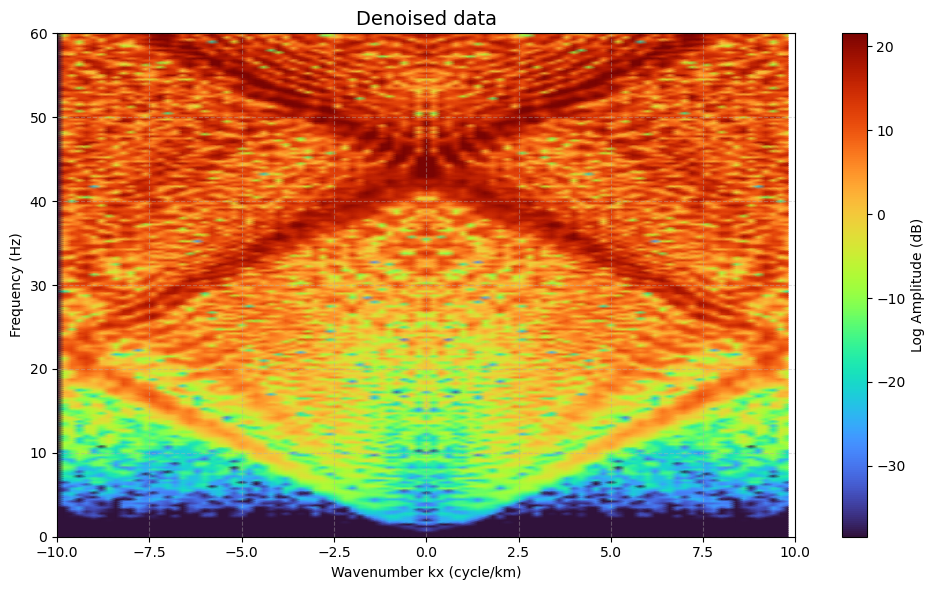

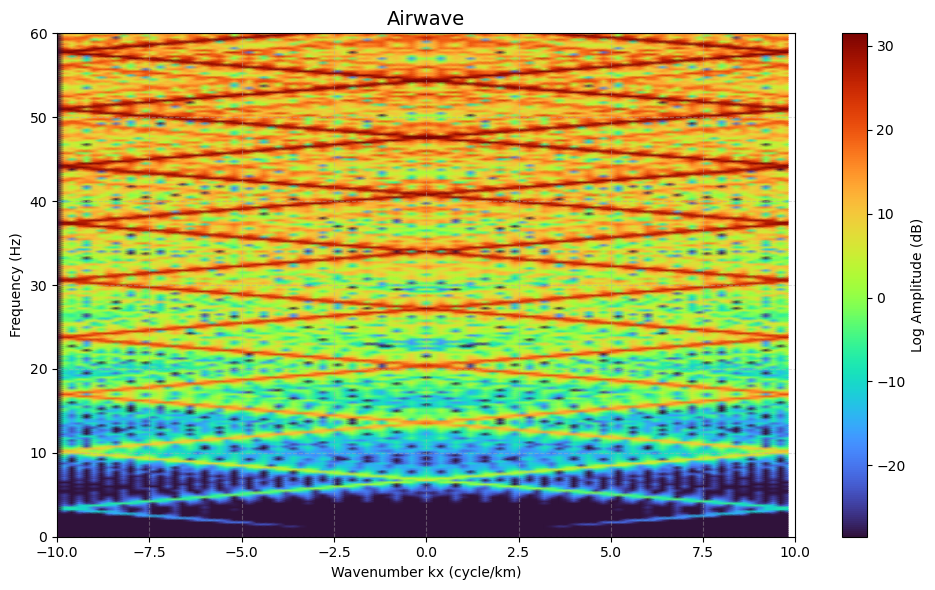

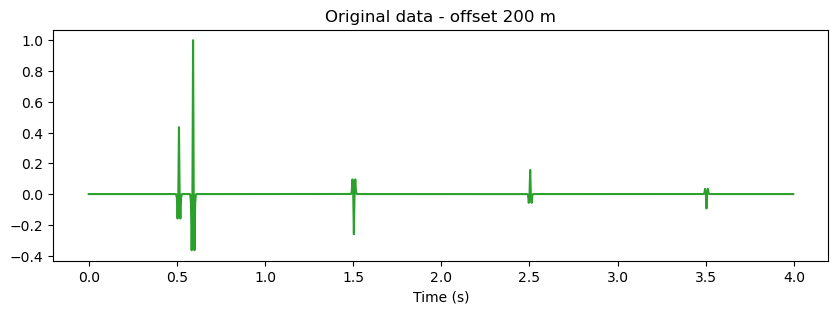

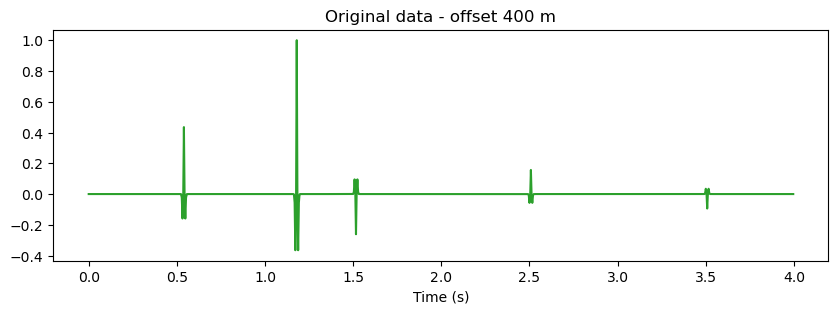

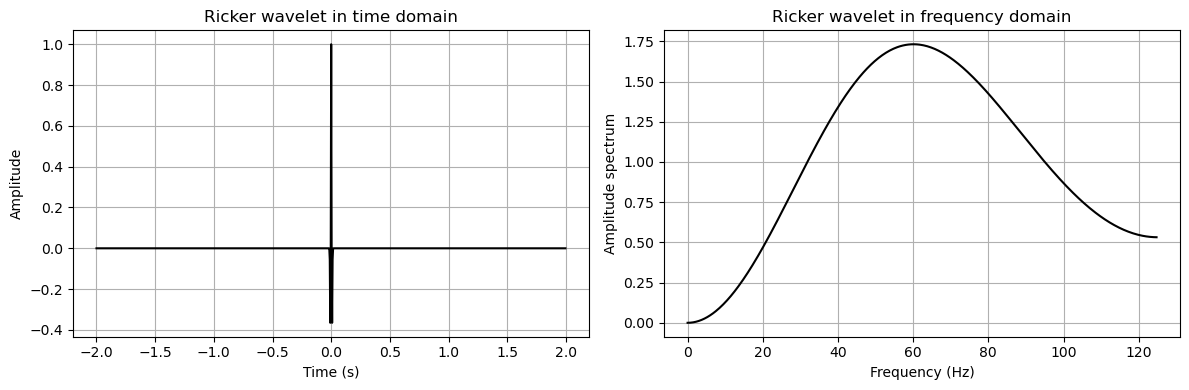

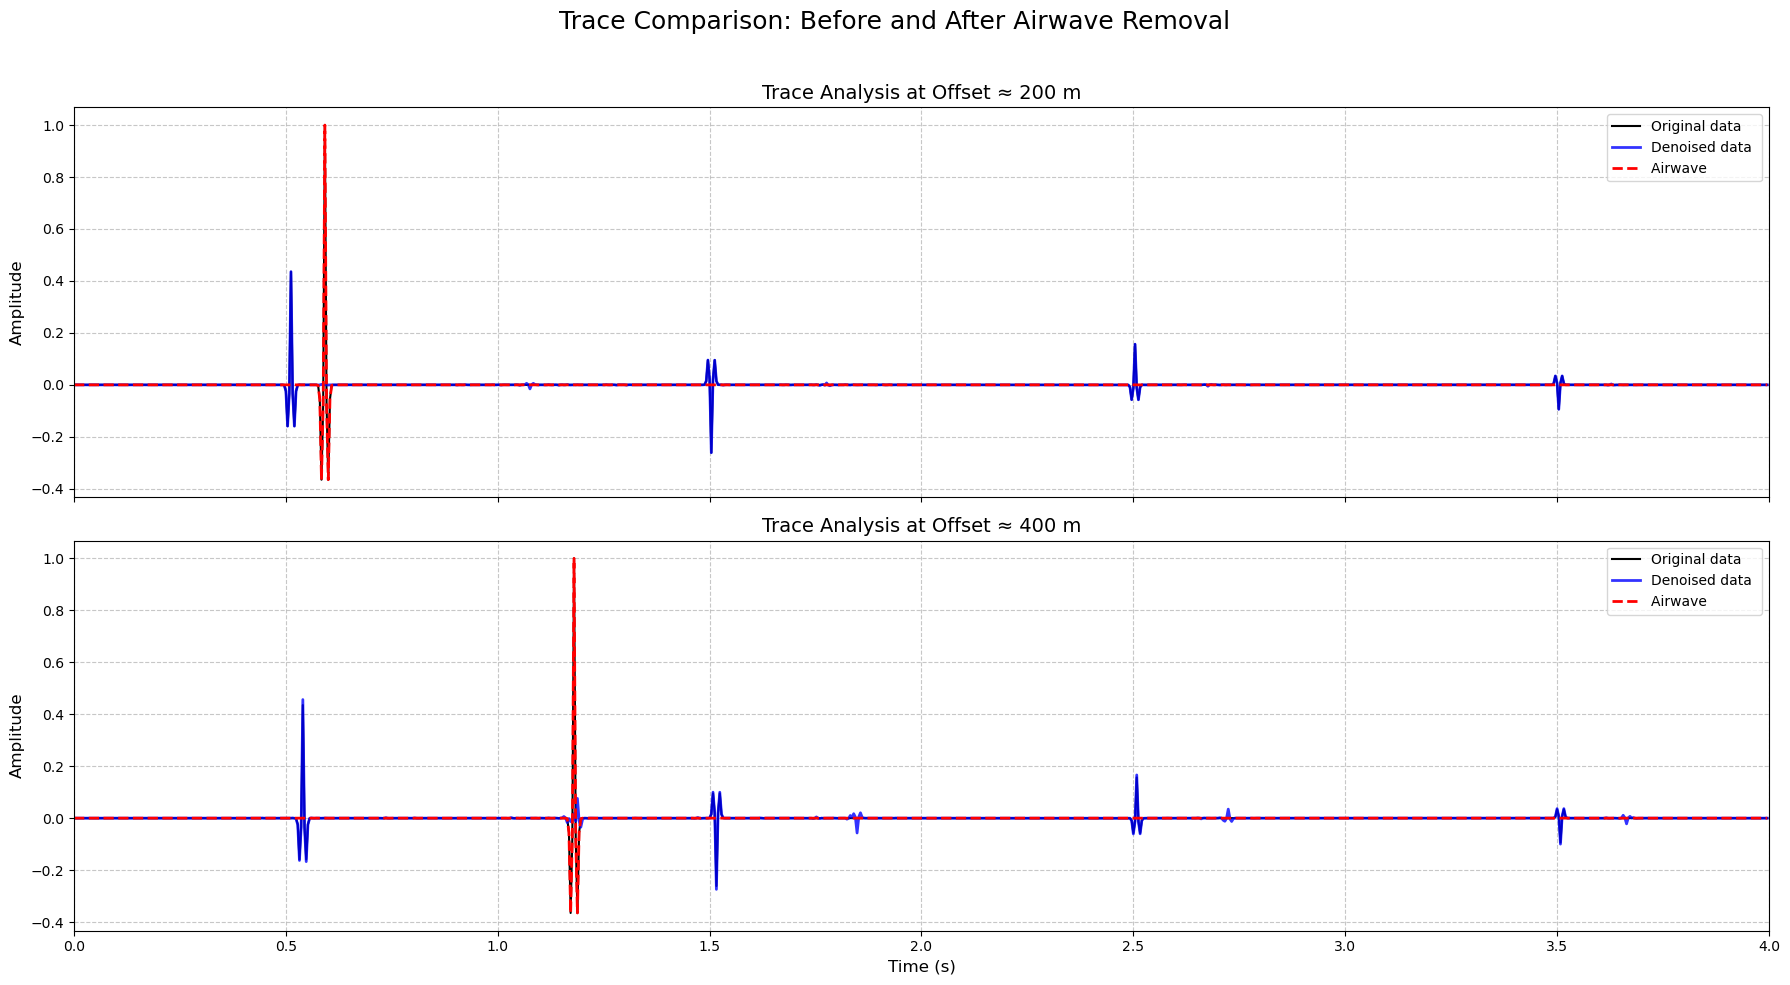

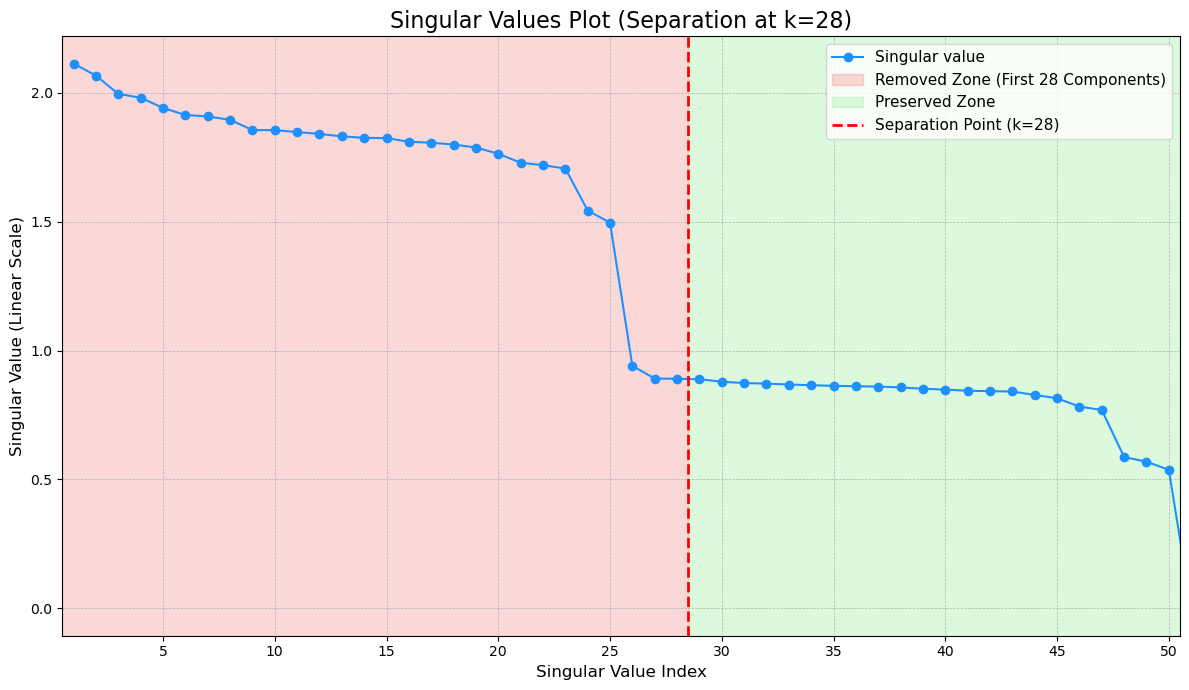

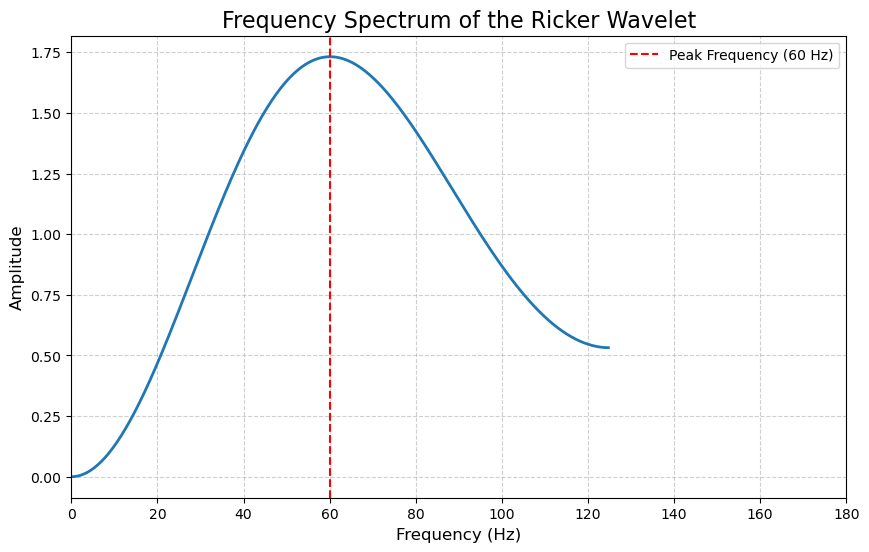

In [1]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
import matplotlib.ticker as mticker

# --- Physical and Survey Parameters ---
vp = np.array([2000, 3500])           # P-wave velocities (m/s)
rho = np.array([2200, 2600])          # Densities (kg/m^3)
dz = 500                              # Layer thickness (m)
f_peak = 60                           # Ricker wavelet peak frequency (Hz)
dt = 0.004                            # Time sampling interval (s)
t_max = 4.0                           # Maximum simulation time (s)
station_interval = 50                 # Distance between receivers (m)
num_stations = 100                    # Total number of receivers
airwave_speed = 340                   # Speed of sound in air (m/s)

t = np.arange(0, t_max, dt)
nt = len(t)

# --- Wavelet Functions ---
def ricker_points(nt, dt, f0):
    t_vals = np.arange(-nt//2, nt//2) * dt
    y = (1 - 2 * (np.pi**2) * (f0**2) * t_vals**2) * np.exp(-np.pi**2 * f0**2 * t_vals**2)
    return y

def ricker_points2(nt, dt, f0):
    t_vals = np.arange(-nt//2, nt//2) * dt
    y = (1 - 2 * (np.pi**2) * (f0**2) * t_vals**2) * np.exp(-np.pi**2 * f0**2 * t_vals**2)
    return y, t_vals

ricker_wavelet = ricker_points(nt, dt, f_peak)
ricker_wavelet /= np.max(np.abs(ricker_wavelet))

# --- Reflection Calculations ---
def reflection_coefficient(vp1, rho1, vp2, rho2):
    return ((vp2 * rho2 - vp1 * rho1) / (vp2 * rho2 + vp1 * rho1))

rc1 = reflection_coefficient(vp[0], rho[0], vp[1], rho[1])
rc_surface = -1

# Calculate vertical two-way travel times for multiples
two_way_time_layer = 2 * dz / vp[0]
travel_times = [two_way_time_layer * (1 + 2 * i) for i in range(4)]

# --- Geometry and Offsets ---
source_position = num_stations // 2
num_offsets = 100
min_offset = 150
offsets = np.linspace(min_offset, min_offset + (num_offsets//2 - 1)*station_interval, num_offsets//2)
offsets = np.concatenate((-offsets[::-1], offsets))  # Symmetric split spread

rc_surface = -1.0
attenuation_factor = 0.6 

# --- Initialize Data Matrices ---
data = np.zeros((len(t), num_stations))
data1 = np.zeros((len(t), num_stations))

# --- Main Simulation Loop ---
for idx, offset in enumerate(offsets):
    offset_abs = abs(offset)
    
    # 1. Simulate Airwave (linear moveout)
    direct_time = offset_abs / airwave_speed
    direct_idx = int(direct_time / dt)
    if direct_idx < len(t):
        data[direct_idx, idx] = 0.8
        data1[direct_idx, idx] = 0.8

    # 2. Simulate Reflections with correct polarity and amplitude
    for i, tt in enumerate(travel_times):
        # Calculate hyperbolic moveout (NMO)
        moveout = np.sqrt(tt**2 + (offset_abs**2) / (vp[0]**2))
        sample_idx = int(moveout / dt)

        if sample_idx < len(t):
            # Calculate amplitude considering:
            # - rc1: initial reflection coefficient
            # - rc_surface**i: polarity reversal per surface bounce (+, -, +, ...)
            # - attenuation_factor**i: amplitude decay for each multiple
            amplitude = rc1 * (rc_surface**i) * (attenuation_factor**i)
            
            # Add spike to data
            data[sample_idx, idx] += amplitude

# --- Convolve with Wavelet ---
for i in range(num_stations):
    data[:, i] = np.convolve(data[:, i], ricker_wavelet, mode='same')

for i in range(num_stations):
    data1[:, i] = np.convolve(data1[:, i], ricker_wavelet, mode='same')

# Normalize
data /= np.max(np.abs(data))
data1 /= np.max(np.abs(data1))

# --- SVD-based Denoising ---
U, s, Vh = svd(data, full_matrices=False)

k_air = 28  # Number of singular values used to reconstruct noise
U_k = U[:, :k_air]
s_k = s[:k_air]
Vh_k = Vh[:k_air, :]
Sigma_k = np.diag(s_k)

# Estimate noise (airwave) using first k components
airwave_estimate = U_k @ Sigma_k @ Vh_k

# Subtract estimate from original data
data_clean = data - airwave_estimate

# --- Visualization Functions ---
def plot_data(data, title, ax):
    im = ax.imshow(data, aspect='auto', cmap='seismic', vmin=-0.5, vmax=0.5,
                    extent=[offsets[0], offsets[-1], t[-1], 0])
    ax.set_title(title)
    ax.set_xlabel('Offset (m)')
    ax.set_ylabel('Time (s)')
    return im

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

plot_data(data_clean+data-data1, 'Denoised data', axs[0])
plot_data(data, 'Data with airwave', axs[1])
plot_data(data1, 'Airwave', axs[2])
plt.tight_layout()
plt.show()

# --- Plot Singular Values ---
max_k_plot = 100
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, max_k_plot + 1), s[:max_k_plot], marker='o', linestyle='-')
plt.xlabel('Singular value Index k')
plt.ylabel('Singular value s')
plt.title('SVD singular values')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# --- F-K Domain Analysis ---
def plot_fk_domain(seismic_section, dt, dx, title="F-K Spectrum", 
                   vmax_percentile=99.5, kx_limit=10, fmax=60):

    nt, nx = seismic_section.shape

    # 2D Fourier Transform and shift to center
    ft2D = np.fft.fft2(seismic_section)
    ft2D_shift = np.fft.fftshift(ft2D)

    # Define Axes
    freq = np.fft.fftshift(np.fft.fftfreq(nt, d=dt))       # Frequency (Hz)
    kx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 1000  # Wavenumber (cycle/km)

    # Calculate Spectral Power (logarithmic dB)
    amplitude = np.abs(ft2D_shift)
    log_amplitude = 20 * np.log10(amplitude + 1e-12)

    # Set color scale limits
    vmax = np.percentile(log_amplitude, vmax_percentile)
    vmin = vmax - 60  # 60 dB dynamic range

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(kx, freq, log_amplitude, cmap='turbo', shading='gouraud', vmin=vmin, vmax=vmax)
    
    plt.title(title, fontsize=14)
    plt.xlabel("Wavenumber kx (cycle/km)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Log Amplitude (dB)")
    
    plt.xlim(-kx_limit, kx_limit)
    plt.ylim(0, fmax)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

dt_sec = dt  
dx_meter = station_interval  

plot_fk_domain(data, dt_sec, dx_meter, title="Data with airwave")
plot_fk_domain(data_clean, dt_sec, dx_meter, title="Denoised data")
plot_fk_domain(data1, dt_sec, dx_meter, title="Airwave")

# --- Individual Trace Plots ---
offset_values = [200, 400]

for offset_val in offset_values:
    idx = np.argmin(np.abs(offsets - offset_val))

    # 1. Data with Airwave
    plt.figure(figsize=(10, 3))
    plt.plot(t, data[:, idx], label="Original data", color='tab:green')
    plt.title(f"Original data - offset {offset_val} m")
    plt.xlabel("Time (s)")

# --- Wavelet Spectral Analysis ---
from scipy.fftpack import fft, fftfreq

ricker_wavelet, t_vals = ricker_points2(nt, dt, f_peak)
ricker_wavelet /= np.max(np.abs(ricker_wavelet))

ricker_wavelet_freq = fft(ricker_wavelet)
freq_axis = fftfreq(nt, d=dt)

pos_mask = freq_axis >= 0
freq_axis = freq_axis[pos_mask]
ricker_wavelet_amp = np.abs(ricker_wavelet_freq[pos_mask])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(t_vals, ricker_wavelet, color='black')
plt.title("Ricker wavelet in time domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(freq_axis, ricker_wavelet_amp, color='black')
plt.title("Ricker wavelet in frequency domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude spectrum")
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Combined Trace Comparison ---
offset_values = [200, 400]

# Create subplots for each offset
fig, axs = plt.subplots(len(offset_values), 1, figsize=(18, 10), sharex=True)
fig.suptitle('Trace Comparison: Before and After Airwave Removal', fontsize=18)

if len(offset_values) == 1:
    axs = [axs]

for i, offset_val in enumerate(offset_values):
    # Find index of closest offset
    idx = np.argmin(np.abs(offsets - offset_val))
    ax = axs[i]

    # --- Extract traces based on user formulas ---
    
    # 1. Original data (with airwave)
    trace_original = data[:, idx]
    
    # 2. Denoised data (using provided custom calculation)
    # Note: This reproduces exactly what was in the source code
    trace_denoised_custom = data_clean[:, idx] + data[:, idx] - data1[:, idx]
    
    # 3. True simulated airwave (as reference)
    trace_airwave_true = data1[:, idx]

    # --- Plotting the lines ---
    ax.plot(t, trace_original, 'k-', label="Original data ", linewidth=1.5)
    ax.plot(t, trace_denoised_custom, 'b-', label="Denoised data ", linewidth=2.0, alpha=0.8)
    ax.plot(t, trace_airwave_true, 'r--', label="Airwave ", linewidth=2.0)

    # --- Plot Formatting ---
    ax.set_title(f"Trace Analysis at Offset ≈ {offset_val} m", fontsize=14)
    ax.set_ylabel("Amplitude", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper right')
    ax.set_xlim(0, t_max)

axs[-1].set_xlabel("Time (s)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Detailed Singular Value Zones ---
k_separation = 28
max_k_plot = 50 

plt.figure(figsize=(12, 7))
plt.plot(np.arange(1, len(s) + 1), s, marker='o', linestyle='-', color='dodgerblue', label='Singular value')

# Annotating zones
# Red zone: first k components usually containing high-energy noise like airwaves
plt.axvspan(0.5, k_separation + 0.5, color='lightcoral', alpha=0.3, label=f'Removed Zone (First {k_separation} Components)')

# Green zone: components usually containing signal/reflections
plt.axvspan(k_separation + 0.5, max_k_plot + 0.5, color='lightgreen', alpha=0.3, label='Preserved Zone')

# Separation line
plt.axvline(x=k_separation + 0.5, color='red', linestyle='--', linewidth=2, label=f'Separation Point (k={k_separation})')

plt.title(f'Singular Values Plot (Separation at k={k_separation})', fontsize=16)
plt.xlabel('Singular Value Index', fontsize=12)
plt.ylabel('Singular Value (Linear Scale)', fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend(fontsize=11)
plt.xlim(0.5, max_k_plot + 0.5)
plt.gca().xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=10))

plt.tight_layout()
plt.show()

# --- Wavelet FFT Plot ---
ricker_fft = np.fft.fft(ricker_wavelet)
freqs = np.fft.fftfreq(nt, d=dt)
positive_freq_mask = freqs >= 0

plt.figure(figsize=(10, 6))
plt.plot(freqs[positive_freq_mask], np.abs(ricker_fft[positive_freq_mask]), linewidth=2)
plt.axvline(f_peak, color='r', linestyle='--', label=f'Peak Frequency ({f_peak} Hz)')

plt.title('Frequency Spectrum of the Ricker Wavelet', fontsize=16)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(0, f_peak * 3) 
plt.show()

# ===================================================================
#           F-K Spectrum of a Single Ricker Wavelet Section
# ===================================================================

# --- Parameters (can be adjusted) ---
f_peak = 60         # Peak frequency of the wavelet
dt = 0.004          # Time sampling interval (s)
t_max = 2.0          # Max time (s)
dx = 25             # Trace interval (m)
num_traces = 101    # Number of traces

# --- Time and Wavelet Generation ---
t = np.arange(0, t_max, dt)
nt = len(t)

ricker_wavelet = ricker_points(256, dt, f_peak) # Short wavelet for section placement

# --- Create a 2D seismic section with only one wavelet ---
seismic_section_wavelet = np.zeros((nt, num_traces))

# Place the wavelet in the center trace at a specific time
center_trace_idx = num_traces // 2
time_idx = nt // 4
start = time_idx
end = start + len(ricker_wavelet)

if end < nt:
    seismic_section_wavelet[start:end, center_trace_idx] = ricker_wavelet